In [ ]:
import os, sys
from pathlib import Path
import numpy as np

# os.environ["CUDA_VISIBLE_DEVICES"] = ""

try:
    __file__
except NameError:
    __file__ = str(Path(os.getcwd())/'notebook.ipynb')  # Convert Path to string
base_dir = os.path.dirname(os.path.abspath(__file__))
# The base_dir variable points to the current directory
parent_dir = os.path.dirname(base_dir)  # Get the parent directory
sys.path.append(parent_dir)  # Add the parent directory to the Python path

from utils.plot_function import AcademicPlot
# Instantiate the plotting class
plotter = AcademicPlot(style='seaborn-v0_8-paper', figsize=(3.2, 2))
#plotter = AcademicPlot(style='seaborn-v0_8-paper', figsize=(6, 4))

%load_ext autoreload
%autoreload 2

# import torch
# torch.cuda.is_available = lambda: False  # Force PyTorch to think CUDA is not available
# device = torch.device('cpu')  # Explicitly set device to CPU

In [2]:
"""load data"""

from data.data_process.data_loader_multi_wecc import prepare_data

fault_idx = [1,2,3,4,5,6,7,8,9,11,14] # fault_idx = [1,2,3,4,5,6,7,8,9,10,11,14]
gen_buses = [1,2,3,6,8]
data_folder_path = os.path.abspath(os.path.join(base_dir, "..", "data/data_folder/IEEE14_1"))
N_traj = len(fault_idx)

# load the data set
# data12 = prepare_data(data_folder_path, fault_idx, 'ieee14_fault_1.2', 1.2)
data = prepare_data(data_folder_path, fault_idx, 'ieee14_fault_1.1', 1.1, phasor_buses=gen_buses)

# seperate timeseries
omega_list =  data['omega_list']
delta_list =  data['delta_list']
time_list =  data['time_list']

# Dataset splitting
np.random.seed(0)  # Set random seed for reproducibility
all_indices = np.arange(N_traj)
np.random.shuffle(all_indices)

# Split dataset
n_train = 9  # Training set size

# Get indices for training and test sets
train_indices = all_indices[:n_train ].tolist()  # First part for training
test_indices = all_indices[n_train:].tolist()    # Remaining for testing

train_Ntraj = len(train_indices)

# Create input data lists with conversion
# Reshape data to [n_features, n_timesteps] * n_trajectories
train_x = [np.concatenate((
    (omega_list[ii]-1)*2*np.pi*60,
    delta_list[ii],
    # data['pe_list'][ii],
    # data['voltage_list'][ii]
), axis=1) for ii in train_indices]          
n_vars_x = train_x[0].shape[-1]                   # = omega + delta + pe

# Reshape data to [n_features, n_timesteps] * n_trajectories
test_x = [np.concatenate((
    (omega_list[ii]-1)*2*np.pi*60,
    delta_list[ii],
    # data['pe_list'][ii],
    # data['voltage_list'][ii]
), axis=1) for ii in test_indices]          # Shape: [n_features, n_timesteps] * n_trajectories

# Print dataset splitting info
print(f"Total trajectories: {N_traj}")
print(f"Training trajectories per fold: {len(train_indices)}")
# print(f"Test trajectories: {len(test_indices)}")

# Similarly process time data
train_time = [time_list[ii] for ii in train_indices]
test_time = [time_list[ii] for ii in test_indices]

# Print data shapes for verification
print("Training data shape:", train_x[0].shape)  # [n_features, n_timesteps] * n_train_trajectories
print("Test data shape:", test_x[0].shape)       # [n_features, n_timesteps] * n_test_trajectories

print("Number of training trajectories:", len(train_x))
print("Number of test trajectories:", len(test_x))

Total fault indices: 11
Loading CSV files for  ieee14_fault_1.1
Extracting Time data
Identifying indices after fault initiation
Slicing data after fault initiation
Total trajectories: 11
Training trajectories per fold: 9
Training data shape: (297, 10)
Test data shape: (297, 10)
Number of training trajectories: 9
Number of test trajectories: 2


In [3]:
import sys
sys.path.append('../src')

import deepkoopman
import numpy as np
# import numpy.random as rnd
np.random.seed(42)  # for reproducibility

# Explicitly disable CUDA in PyTorch
import torch
# torch.cuda.is_available = lambda: False  # Force PyTorch to think CUDA is not available
# device = torch.device('cpu')  # Explicitly set device to CPU
# torch.set_float32_matmul_precision('high')

import warnings
warnings.filterwarnings('ignore')

# __Read Loss-Values from CSV File__

In [ ]:
# Fehler aus log Datei auslesen


import pandas as pd

# CSV einlesen
#df = pd.read_csv("IEEE_results/hybrid/allinone/deephodmd_results_allinone_multitimescale/epoch_losses.csv")
#df = pd.read_csv("IEEE_results/hybrid/ffjord/deephodmd_results_ffjord_kernel/epoch_losses.csv")
#df = pd.read_csv("IEEE_results/hybrid/ffjord/deephodmd_results_ffjord_multitimescale/epoch_losses.csv")
#df = pd.read_csv("IEEE_results/base/deephodmd_results_glow/epoch_losses.csv")
#df = pd.read_csv("IEEE_results/base/deephodmd_results_iresnet_new/epoch_losses.csv")
#df = pd.read_csv("IEEE_results/base/deephodmd_results_nice/epoch_losses.csv")
#df = pd.read_csv("IEEE_results/hybrid/iResNet/deephodmd_results_iresnet_cnn/epoch_losses.csv")
#df = pd.read_csv("IEEE_results/hybrid/iResNet/deephodmd_results_iresnet_kernel/epoch_losses.csv")
#df = pd.read_csv("IEEE_results/hybrid/iResNet/deephodmd_results_iresnet_multitimescale/epoch_losses.csv")



# Anzahl der letzten Epochen, über die gemittelt werden soll
n_last = 5

# Letzte n_last Zeilen auswählen
last_epochs = df.tail(n_last)

# Mittelwert pro Loss-Spalte berechnen
mean_values = last_epochs.mean()

print(f"Mittelwerte der letzten {n_last} Epochen (Zeilen {last_epochs.index.tolist()}):")
for col in df.columns:
    mean_val = mean_values[col]
    print(f"{col}: Mittelwert = {mean_val}")



# __Load Models__

In [7]:
# Modelle laden
from deepkoopman.regression import DeepKoopman
import torch

# Liste mit Modell-Dateipfaden (beliebig erweiterbar)
model_paths = [
    #'IEEE_results/hybrid/allinone/deephodmd_results_allinone_multitimescale/dlk_allinone_multitimescale.pth',
    #'IEEE_results/hybrid/allinone/deephodmd_results_allinone_kernel/dlk_allinone_kernel.pth',
    #'IEEE_results/hybrid/allinone/deephodmd_results_allinone_cnn/dlk_allinone_cnn.pth',
    
    #'IEEE_results/hybrid/glow/deephodmd_results_glow_multitimescale/dlk_glow_multitimescale.pth',
    #'IEEE_results/hybrid/glow/deephodmd_results_glow_kernel/dlk_glow_kernel.pth',
    #'IEEE_results/hybrid/glow/deephodmd_results_glow_cnn/dlk_glow_cnn.pth',

    #'IEEE_results/hybrid/ffjord/deephodmd_results_ffjord_multitimescale/dlk_ffjord_multitimescale.pth',
    #'IEEE_results/hybrid/ffjord/deephodmd_results_ffjord_kernel/dlk_ffjord_kernel.pth',
    #'IEEE_results/hybrid/ffjord/deephodmd_results_ffjord_cnn/dlk_ffjord_cnn.pth',

    #'IEEE_results/hybrid/nice/deephodmd_results_nice_multitimescale/dlk_nice_multitimescale.pth',
    #'IEEE_results/hybrid/nice/deephodmd_results_nice_kernel/dlk_nice_kernel.pth',
    #'IEEE_results/hybrid/nice/deephodmd_results_nice_cnn/dlk_nice_cnn.pth',

    #'IEEE_results/hybrid/iResNet/deephodmd_results_iresnet_cnn/dlk_iresnet_cnn.pth',
    #'IEEE_results/hybrid/iResNet/deephodmd_results_iresnet_kernel/dlk_iresnet_kernel.pth',
    #'IEEE_results/hybrid/iResNet/deephodmd_results_iresnet_multitimescale/dlk_iresnet_multitimescale.pth',    


    #'IEEE_results/base/deephodmd_results_allinone/dlk_allinone.pth',
    #'IEEE_results/base/deephodmd_results_glow/dlk_glow.pth',
    #'IEEE_results/base/deephodmd_results_nice/dlk_nice.pth',
    #'IEEE_results/base/deephodmd_results_ffjord/dlk_ffjord.pth',
    #'IEEE_results/base/deephodmd_results_hint/dlk_hint.pth',
    #'IEEE_results/base/deephodmd_results_realnvp/dlk_realnvp.pth',
    #'IEEE_results/base/deephodmd_results_iresnet/dlk_iresnet.pth',


    'IEEE_results/base/id_base/id_base.pth',
    'IEEE_results/hybrid/id/id_cnn/id_cnn.pth',
    'IEEE_results/hybrid/id/id_kernel/id_kernel.pth',
    'IEEE_results/hybrid/id/id_multitimescale/id_multitimescale.pth'

    # hier weitere Pfade ergänzen
]

# Dictionary zum Speichern der geladenen Modelle
models = {}

for path in model_paths:
    print(f"Lade Modell aus: {path}")
    checkpoint = torch.load(path, map_location='cpu')

    input_size = checkpoint['config_inn']['input_size']
    output_size = checkpoint['config_inn']['output_size']
    time_delay_embed = checkpoint['time_delay']
    state_dim = input_size // time_delay_embed
    if checkpoint['config_inn']['extension_config'] is None:
        extension_dim = 0
    else:
        extension_dim = checkpoint['config_inn']['extension_config']['extension_output_size']
    data_dt = data['time_list'][0][1] - data['time_list'][0][0]

    # DeepKoopman Modell rekonstruieren
    model = DeepKoopman(
        dt=data_dt,
        look_forward=checkpoint["look_forward"],
        time_delay=time_delay_embed,
        config_inn=checkpoint["config_inn"],
        batch_size=32,
        normalize=True,
        progressive_steps=True,
        trainer_kwargs={'max_epochs': 1, 'accelerator': 'cpu'}
    )

    # Zustand laden
    model._regressor.load_state_dict(checkpoint["inn_state_dict"])
    model.losses_ = checkpoint.get("losses", None)
    model.dm = model._prepare_data(train_x, None, dt=data_dt)
    model.extension_dim = extension_dim
    #model._state_matrix_ = checkpoint['koopman_operator']

    # Zusätzliche gespeicherte Werte setzen
    model._eigenvalues_ = checkpoint.get("eigenvalues", None)
    model._eigenvectors_ = checkpoint.get("eigenvectors", None)

    print("✅ Modell erfolgreich geladen und einsatzbereit.")
    print('inn_type', checkpoint.get("inn_type", "unbekannt"))

    # Als Schlüssel im Dict verwenden wir den Dateinamen ohne Pfad und Endung
    key = path.split('/')[-1].replace('.pth', '')
    models[key] = model




Lade Modell aus: IEEE_results/base/id_base/id_base.pth
✅ Modell erfolgreich geladen und einsatzbereit.
inn_type id
Lade Modell aus: IEEE_results/hybrid/id/id_cnn/id_cnn.pth
✅ Modell erfolgreich geladen und einsatzbereit.
inn_type id
Lade Modell aus: IEEE_results/hybrid/id/id_kernel/id_kernel.pth
✅ Modell erfolgreich geladen und einsatzbereit.
inn_type id
Lade Modell aus: IEEE_results/hybrid/id/id_multitimescale/id_multitimescale.pth
✅ Modell erfolgreich geladen und einsatzbereit.
inn_type id


# __Plot RNN Loss over Epochs__

In [ ]:
import pandas as pd

# Dateipfade und Labels
csv_files = [
    "IEEE_results/base/deephodmd_results_allinone/epoch_losses.csv",
    "IEEE_results/base/deephodmd_results_realnvp/epoch_losses.csv",
    "IEEE_results/base/deephodmd_results_nice/epoch_losses.csv",
    "IEEE_results/base/deephodmd_results_glow/epoch_losses.csv",
    "IEEE_results/base/deephodmd_results_hint/epoch_losses.csv",
    "IEEE_results/base/deephodmd_results_ffjord/epoch_losses.csv",
]
labels = ["All-In-One", "RealNVP", "Nice", "GLOW", "HINT", "FFJORD"]

# Listen für x- und y-Werte vorbereiten
x_list = []
y_list = []

# CSVs einlesen und Daten extrahieren
for file in csv_files:
    df = pd.read_csv(file)
    x_list.append(df["epoch"].values)           # Epochen
    y_list.append(df["avg_rnn_loss"].values)    # avg_rnn_loss

# Plot aufrufen
plotter.plot(
    x_list=x_list,
    y_list=y_list,
    labels=labels,
    xlabel="Epoch",
    ylabel="Avg RNN Loss",
    title="Training Curves: avg_rnn_loss",
    plot_legend=True,
    plot_grid=False,  # Grid ausschalten
    y_scale = 'log',
    bbox_to_anchor=None,
    legend_loc="upper left"
)


# __Plot Training Time__

In [ ]:
import matplotlib.pyplot as plt
from matplotlib import rcParams

# LaTeX aktivieren
rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],  # klassische LaTeX-Schrift
    "axes.labelsize": 8,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 8
})


models = ["All-In-One", "RealNVP", "Glow", "Nice", "iResNet", "HINT", "ODE-based"]
times = [29, 38, 20, 24, 485, 240, 94]

plt.figure(figsize=(4,3))
plt.bar(models, times, color='skyblue')
plt.ylabel("Training Time (min)")
plt.title("Training Time Comparison")
plt.xticks(rotation=30, fontsize=10, ha='right')  # ha='right' für bessere Ausrichtung

plt.savefig("wallclockTimeIEEE.pdf", bbox_inches='tight')
plt.show()



# __RMSE and RRMSE for Training Trajectory 0__

In [ ]:
import matplotlib.pyplot as plt

ii = 0
x0 = train_x[ii][0:time_delay_embed].reshape(-1)  # np.array([2, -4])
t = train_time[ii] - train_time[ii][0]

# Dictionaries für Fehler, falls noch nicht initialisiert
if 'rmse_errors' not in globals():
    rmse_errors = {key: [None]*train_Ntraj for key in models.keys()}
    rrmse_factors = {key: [None]*train_Ntraj for key in models.keys()}

for key, model in models.items():
    sol = model.simulate(x0[np.newaxis, :], n_steps=len(t)-1)[:, :state_dim]

    rmse_errors[key][ii] = np.linalg.norm(train_x[ii][:, :state_dim] - sol.real)**2
    rrmse_factors[key][ii] = np.linalg.norm(train_x[ii][:, :state_dim])**2



# __Relative Error on training data__

In [8]:
rmse_errors_train = {key: [None]*train_Ntraj for key in models.keys()}
rrmse_factors_train = {key: [None]*train_Ntraj for key in models.keys()}

for ii in range(train_Ntraj):
    x0 = train_x[ii][0:time_delay_embed].reshape(-1)  #np.array([2, -4])
    t = train_time[ii]-train_time[ii][0]

    for key, model in models.items():
        sol = model.simulate(x0[np.newaxis, :], n_steps=len(t)-1)[:,:state_dim]  
        rmse_errors_train[key][ii]  = np.linalg.norm(train_x[ii][:,:state_dim] - sol.real)**2 
        rrmse_factors_train[key][ii] = np.linalg.norm(train_x[ii][:,:state_dim])**2

abs_err_train_dict = {}
rel_err_train_dict = {}

for key in models.keys():
    abs_err_train = np.sqrt(sum(rmse_errors_train[key]))
    rel_err_train = np.sqrt(sum(rmse_errors_train[key]) / sum(rrmse_factors_train[key])) * 100
    
    abs_err_train_dict[key] = abs_err_train
    rel_err_train_dict[key] = rel_err_train
    
    print(f"Absolute error on training data {key}: {abs_err_train:.6f}")
    print(f"Relative error on training data {key}: {rel_err_train:.2f} %\n")


Absolute error on training data id_base: 22.994118
Relative error on training data id_base: 41.46 %

Absolute error on training data id_cnn: 20.329814
Relative error on training data id_cnn: 36.66 %

Absolute error on training data id_kernel: 23.676614
Relative error on training data id_kernel: 42.69 %

Absolute error on training data id_multitimescale: 12.771945
Relative error on training data id_multitimescale: 23.03 %



# __Relative Error on test data__

In [9]:
# Dictionary zum Speichern der Fehlerwerte je Modell auf Testdaten
rmse_errors_test = {key: [None]*len(test_x) for key in models.keys()}
rrmse_factors_test = {key: [None]*len(test_x) for key in models.keys()}

for ii in range(len(test_x)):
    x0 = test_x[ii][0:time_delay_embed].reshape(-1)
    t = test_time[ii] - test_time[ii][0]

    for key, model in models.items():
        sol = model.simulate(x0[np.newaxis, :], n_steps=len(t)-1)[:, :state_dim]
        rmse_errors_test[key][ii] = np.linalg.norm(test_x[ii][:, :state_dim] - sol.real)**2
        rrmse_factors_test[key][ii] = np.linalg.norm(test_x[ii][:, :state_dim])**2

abs_err_test_dict = {}
rel_err_test_dict = {}
# Ausgabe der Fehler für jedes Modell auf Testdaten
for key in models.keys():
    abs_err_test = np.sqrt(sum(rmse_errors_test[key]))
    rel_err_test = np.sqrt(sum(rmse_errors_test[key]) / sum(rrmse_factors_test[key])) * 100
    
    # Speichern
    abs_err_test_dict[key] = abs_err_test
    rel_err_test_dict[key] = rel_err_test
    
    # Ausgabe
    print(f"Absolute error on test data {key}: {abs_err_test:.6f}")
    print(f"Relative error on test data {key}: {rel_err_test:.2f} %\n")


Absolute error on test data id_base: 12.641429
Relative error on test data id_base: 40.43 %

Absolute error on test data id_cnn: 14.365634
Relative error on test data id_cnn: 45.94 %

Absolute error on test data id_kernel: 13.962152
Relative error on test data id_kernel: 44.65 %

Absolute error on test data id_multitimescale: 9.837894
Relative error on test data id_multitimescale: 31.46 %



# __Generalization Gap Plot for Base INNs__

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Generalization Gap
gen_gap = {key: rel_err_test_dict[key] - rel_err_train_dict[key] for key in models.keys()}

model_names = list(gen_gap.keys())
gap_values = [gen_gap[key] for key in model_names]

plt.rcParams.update({"text.usetex": True})  # LaTeX Schrift

fig, ax = plt.subplots(figsize=(4,3))

colors = ['skyblue']
bars = ax.bar(np.arange(len(gap_values)), gap_values, color=colors, bottom=0.0)  # Indizes als x

# Null-Linie
ax.axhline(0, color='k', linewidth=0.8)

ax.set_ylabel(r'Generalization Gap [\%]')

# Custom x-axis labels
custom_labels = [r"All-In-One", r"Glow", r"Nice", r"ODE-based", "HINT", "RealNVP", "iResNet"]
ax.set_xticks(np.arange(len(gap_values)))
ax.set_xticklabels(custom_labels, fontsize=10, rotation=30, ha="right")

# Achse erweitern
ymin = min(gap_values) - 5
ymax = max(gap_values) + 5
ax.set_ylim(ymin, ymax)

# Beschriftungen auf den Bars
for bar, gap in zip(bars, gap_values):
    height = bar.get_height()
    if height >= 0:
        ax.text(bar.get_x() + bar.get_width()/2, height + 0.5, f'{gap:.2f}\%', 
                ha='center', va='bottom', fontsize=10)
    else:
        ax.text(bar.get_x() + bar.get_width()/2, height - 0.5, f'{gap:.2f}\%', 
                ha='center', va='top', fontsize=10)

plt.tight_layout()
plt.savefig("GeneralizationGapBase.pdf")
plt.show()

# __Generalization Gap Plot for Hybrid INNs__

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch

# ---- Daten wie gehabt ----
inn_names = ['dlk_allinone', 'dlk_glow', 'dlk_nice', 'dlk_ffjord', 'dlk_iresnet']
extensions = ['None', 'CNN', 'Multitimescale', 'Kernel']
colors = {'None': 'gray', 'CNN': 'skyblue', 'Multitimescale': 'lightgreen', 'Kernel': 'salmon'}

gen_gap_hybrid = {}
for inn in inn_names:
    gen_gap_hybrid[inn] = {}
    for ext in extensions:
        if ext == 'None':
            key = inn
        else:
            key = f"{inn}_{ext.lower()}"
        if key in rel_err_train_dict and key in rel_err_test_dict:
            gen_gap_hybrid[inn][ext] = rel_err_test_dict[key] - rel_err_train_dict[key]
        else:
            gen_gap_hybrid[inn][ext] = 0.0

# ---- Plot Einstellungen ----
bar_width = 0.15
group_spacing = 0.4

positions = []
current_pos = 0
for inn in inn_names:
    positions.append([current_pos + i*bar_width for i in range(len(extensions))])
    current_pos += len(extensions)*bar_width + group_spacing

plt.rcParams.update({
    "text.usetex": True,
    "font.size": 13,
    "axes.labelsize": 14,
    "axes.titlesize": 15,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "legend.fontsize": 12
})

fig, ax = plt.subplots(figsize=(6.5,4.5), dpi=300)

for inn_idx, inn in enumerate(inn_names):
    for ext_idx, ext in enumerate(extensions):
        val = gen_gap_hybrid[inn][ext]
        ax.bar(positions[inn_idx][ext_idx], val, width=bar_width, color=colors[ext])


# Null-Linie
ax.axhline(0, color='k', linewidth=0.8)

inn_labels = {
    "dlk_allinone": "All-In-One",
    "dlk_glow": "Glow",
    "dlk_nice": "NICE",
    "dlk_iresnet":"iResNet",
    "dlk_ffjord": "ODE"
}

group_centers = [np.mean(pos) for pos in positions]
ax.set_xticks(group_centers)
ax.set_xticklabels([inn_labels[inn] for inn in inn_names], fontsize=13)

# Grid einblenden
ax.grid(True, linestyle="--", linewidth=0.7, alpha=0.7)

ax.set_ylabel(r'Generalization Gap [\%]')
ax.set_title(r'Generalization Gap for Base INN and Extensions')

# Legende oben in einer Reihe
legend_handles = [Patch(color=colors[ext], label=ext) for ext in extensions]
ax.legend(handles=legend_handles,
          loc="upper center", bbox_to_anchor=(0.5, 1.32), ncol=len(extensions), frameon=False)

plt.tight_layout()
plt.savefig("GeneralizationGapBaseHybrid.pdf", bbox_inches="tight")
plt.show()


# __Plot Model Performance for Training Trajectory train_idx__

dlk_allinone: shape (334, 40)
dlk_ffjord: shape (334, 40)
dlk_iresnet: shape (334, 40)


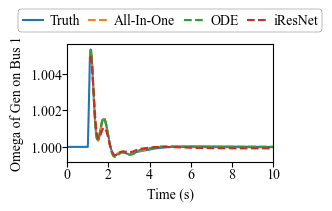

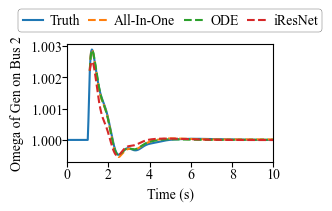

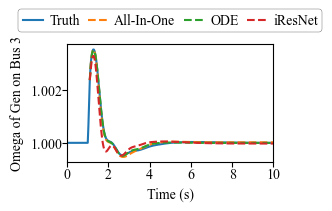

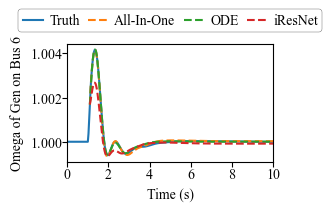

In [ ]:
train_idx = 4

x0 = train_x[train_idx][0:time_delay_embed].reshape(-1)  # np.array([2, -4])
T = 10
t = np.arange(0, T, data_dt)

X_train = train_x[train_idx][:len(t)]

# Simulationen für alle Modelle
simulations = {}
for key, model in models.items():
    sol = model.simulate(x0[np.newaxis, :], n_steps=len(t)-1)
    # Transformation falls nötig (kannst anpassen, falls unterschiedliche Modelle verschiedene Transformationen brauchen)
    sol = sol / (2 * np.pi * 60) + 1
    simulations[key] = sol

train_traj_idx = train_indices[train_idx]
time_train_complete = data['origin_time'][train_traj_idx]
omega_train_complete = data['origin_omega'][train_traj_idx]

# Farben für Modelle dynamisch zuweisen (plus Truth in blau)
import matplotlib.cm as cm
#colors = ['blue', 'red', 'green', 'orange', 'purple', 'yellow'] 

# Nur bestimmte Modelle plottbar machen
selected_models = ['dlk_allinone','dlk_ffjord','dlk_iresnet']  # nur diese Keys aus `models`
for key in selected_models:
    print(f"{key}: shape {simulations[key].shape}")


labels = ['Truth'] + ["All-In-One"] + ["ODE"] + ["iResNet"]  

for var_id in [0,1,2,3]:
    # Zeitachsen: Truth und die Simulationen der ausgewählten Modelle
    plotter.plotAcademic(
        [time_train_complete, *(t + train_time[train_idx][0] for key in selected_models)],
        [omega_train_complete[:, var_id]] + [simulations[key][:, var_id].real for key in selected_models],
        labels=labels,
        xlabel="Time (s)",
        ylabel=f"Omega of Gen on Bus {gen_buses[var_id]}",
        title=None,
        linestyles=['-'] + ['--'] * len(selected_models),
        filename=f"GlowHybrid_Train4_Bus{gen_buses[var_id]}.pdf",
        #filename=None,
        xlim=(0, 10),
        xticks=np.linspace(0, 10, 6),
        plot_legend=True,
        plot_grid=False
    )


# __Performance on Test Trajectory 0__

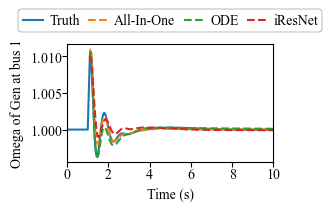

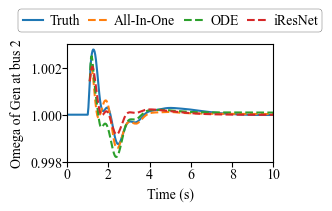

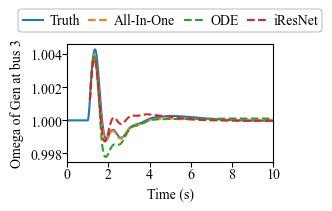

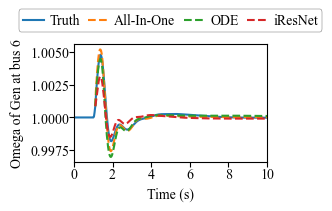

In [8]:
test_idx = 0
x0 = test_x[test_idx][0:time_delay_embed].reshape(-1)
T = 10
t = np.arange(0, T, data_dt)
Xtest = test_x[test_idx][:len(t)]

# Simulationen für alle Modelle
simulations = {}
for key, model in models.items():
    sol = model.simulate(x0[np.newaxis, :], n_steps=len(t)-1)
    sol = sol / (2 * np.pi * 60) + 1
    simulations[key] = sol

test_traj_idx = test_indices[test_idx]
time_test_complete = data['origin_time'][test_traj_idx]
omega_test_complete = data['origin_omega'][test_traj_idx]

# Farben & Labels für Plot
import matplotlib.cm as cm
# Nur bestimmte Modelle plottbar machen
selected_models = ['dlk_allinone','dlk_ffjord','dlk_iresnet']  # nur diese Keys aus `models`

labels = ['Truth'] + ["All-In-One"] + ["ODE"] + ["iResNet"]  
for var_id in [0,1,2,3]:
    plotter.plotAcademic(
        [time_test_complete] + [t + test_time[test_idx][0]] * len(models),
        [omega_test_complete[:, var_id]] + [simulations[key][:, var_id].real for key in models.keys()],
        labels=labels,
        xlabel="Time (s)",
        ylabel=f"Omega of Gen at bus {gen_buses[var_id]}",
        title=None,
        linestyles=['-'] + ['--'] * len(selected_models),
        filename=f"Comparison_Test0_{gen_buses[var_id]}.pdf",
        #filename=None,
        xlim=(0, 10),
        xticks=np.linspace(0, 10, 6),
        plot_legend=True,
        plot_grid=False
    )


# __Performance on Test Trajectory 1__

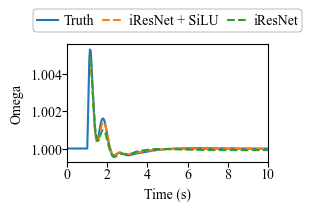

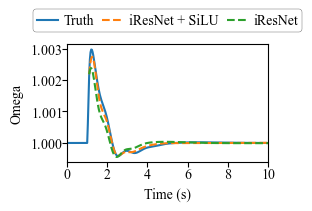

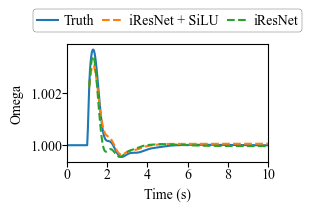

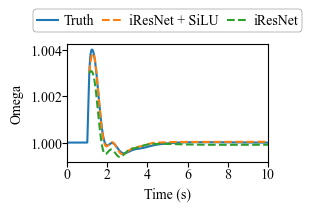

In [ ]:
test_idx = 1
x0 = test_x[test_idx][0:time_delay_embed].reshape(-1)
T = 10
t = np.arange(0, T, data_dt)
Xtest = test_x[test_idx][:len(t)]

# Simulationen für alle Modelle
simulations = {}
for key, model in models.items():
    sol = model.simulate(x0[np.newaxis, :], n_steps=len(t)-1)
    sol = sol / (2 * np.pi * 60) + 1
    simulations[key] = sol

test_traj_idx = test_indices[test_idx]
time_test_complete = data['origin_time'][test_traj_idx]
omega_test_complete = data['origin_omega'][test_traj_idx]



# Farben & Labels fürs Plotten (Truth + Modelle)
import matplotlib.cm as cm

selected_models = ['dlk_iresnet_multitimescale','dlk_iresnet']  # nur diese Keys aus `models`

labels = ['Truth'] + ["iResNet + SiLU"] + ["iResNet"]  

for var_id in [0, 1, 2, 3]:
    plotter.plotAcademic(
        [time_test_complete] + [t + test_time[test_idx][0]] * len(models),
        [omega_test_complete[:, var_id]] + [simulations[key][:, var_id].real for key in models.keys()],
        labels=labels,
        xlabel="Time (s)",
        ylabel=f"Omega",
        title=None,
        linestyles=['-'] + ['--'] * len(selected_models),
        filename=f"iResNetHybrid_Test1_Bus{gen_buses[var_id]}.pdf",
        #filename= None,
        xlim=(0, 10),
        xticks=np.linspace(0, 10, 6),
        plot_legend=True,
        plot_grid=False
    )


# __Koopman Modal Analysis__

# __Save coefficients of Koopman eigenfunctions for all models__

In [ ]:
psi_t_all = {}  # Zum Speichern der psi_t für alle Modelle, koeffizient der eigenfunktion
#phi is observable

T = 10
t = np.arange(0, T, data_dt)

for key, model in models.items():
    psi_0 = model._compute_psi(x0)  # (n_koopman, n_samples)
    psi_t = np.zeros((state_dim*time_delay_embed+model.extension_dim, len(t)))  # (n_koopman, n_samples)
    for tt in range(len(t)):
        psi_t[:, tt] = (np.diag(np.power(model._eigenvalues_, tt)) @ psi_0)[:, -1]
    psi_t_all[key] = psi_t


# __Plot Psi 0__

In [ ]:
var_id = 0

plot_curves = [psi_t_all[key][var_id] for key in models.keys()]  # alle Kurven
labels = ["GLOW"]  # Modellnamen als Labels

plotter.plot(
    [t] * len(models),
    plot_curves,
    labels=labels,
    xlabel="Time (s)",
    ylabel=f"$\psi_{{{var_id}}}$",
    title=None,
    linestyles=['-'] * len(models),
    filename=None,
    xlim=(0, T),
    xticks=np.linspace(0, 10, 6),
    plot_legend=True,
    plot_grid=False
)

# __Absolute values of Eigenvalues__

In [ ]:
# Beispiel: Betragswerte der Eigenwerte für alle Modelle ausgeben
for key, model in models.items():
    abs_eigenvalues = abs(model._eigenvalues_)
    print(f"Absolutwerte der Eigenwerte für Modell '{key}':")
    print(abs_eigenvalues)


# __Plot Eigenvalues on Unit Circle__

In [ ]:
from plot_function import plot_eigs
for key, model in models.items():
    print(f"Eigenwerte für Modell '{key}':")
    filename = f"eigenvalues_{key}.pdf"
    plot_eigs(model._eigenvalues_,filename)


# __Print log of eigenvalues__

In [ ]:
for name, model in models.items():
    eigv = np.log(model._eigenvalues_) / data_dt
    print(f"Eigenvalues (log) für Modell '{name}':")
    print(eigv)
    print()

# __Print Modes__

In [ ]:
mode_i = 0
train_idx = 0  # Oder welcher Index auch immer passt

for name, model in models.items():
    psi_x = model.psi(train_x[train_idx][0:time_delay_embed].reshape(-1))  # psi(x) direkt aus dem Modell
    tmp = model._eigenvectors_[:, [mode_i]] @ psi_x[[mode_i], :]
    print(f"Modell '{name}':")
    print(tmp)
    print("Norm:", np.linalg.norm(tmp))
    print()


# __Get Eigenvectors and eigenvalues__

In [5]:

eigs = model._eigenvalues_
vecs = model._eigenvectors_

print("Eigenvalues:", eigs)
print("Eigenvectors:", vecs)

Eigenvalues: [0.9467059 +0.17869565j 0.9467059 -0.17869565j 0.9484019 +0.15466496j
 0.9484019 -0.15466496j 0.9489961 +0.12442751j 0.9489961 -0.12442751j
 0.96097505+0.1028662j  0.96097505-0.1028662j  0.950149  +0.08105922j
 0.950149  -0.08105922j 0.93553424+0.06450339j 0.93553424-0.06450339j
 0.95470655+0.06176915j 0.95470655-0.06176915j 0.9440613 +0.04966949j
 0.9440613 -0.04966949j 0.9566523 +0.04545195j 0.9566523 -0.04545195j
 0.93219846+0.j         0.99808073+0.j         0.96491325+0.03579326j
 0.96491325-0.03579326j 0.9422112 +0.01474906j 0.9422112 -0.01474906j
 0.94488657+0.j         0.98677784+0.j         0.97669405+0.01773005j
 0.97669405-0.01773005j 0.9594236 +0.02739229j 0.9594236 -0.02739229j
 0.9620821 +0.02591646j 0.9620821 -0.02591646j 0.95842355+0.02093744j
 0.95842355-0.02093744j 0.9712005 +0.0149446j  0.9712005 -0.0149446j
 0.97823775+0.00134078j 0.97823775-0.00134078j 0.9624991 +0.00187424j
 0.9624991 -0.00187424j]
Eigenvectors: [[ 0.04841394+0.02462909j  0.04841394-0

# __Print Mode and Eigenvalues__

In [ ]:
# Diskrete Eigenwerte -> kontinuierliche λ = log(λ_d)/Δt
dt = data_dt  # dein Zeitschritt
cont_eigs = np.log(eigs) / dt  

freqs = np.imag(cont_eigs) / (2*np.pi)  # Frequenz in Hz
damps = np.real(cont_eigs)              # Dämpfungsraten

for i, (lam, f, d) in enumerate(zip(eigs, freqs, damps)):
    print(f"Mode {i}: λ={lam:.3f}, freq={f:.3f} Hz, damping={d:.3f}")

# __Plot Time Evolution and Participation Factors of the strongest 5 Koopman Modes__

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FormatStrFormatter


time_steps = 100
n_modes_to_plot = 5  # wie viele Modi darstellen

for name, model in models.items():
    eigvecs = np.array(model._eigenvectors_)             # shape (n_modes, n_modes)
    eigvals = np.array(model._eigenvalues_).flatten()    # shape (n_modes,)
    psi_0 = model._compute_psi(x0)                       # (n_koopman, n_samples)

    # Initial state als Spaltenvektor
    x0_proj = np.array(psi_0[:, -1]).reshape(-1,1)

    # Projekt auf die Eigenmoden
    coeffs = np.linalg.inv(eigvecs) @ x0_proj

    # Zeitliche Entwicklung der Modi
    X_modes = np.zeros((eigvecs.shape[0], time_steps), dtype=complex)
    for t in range(time_steps):
        X_modes[:, t] = (eigvecs @ (coeffs.flatten() * eigvals**t)).flatten()

    # Top-Modi bestimmen
    mode_strength = np.max(np.abs(X_modes[:,10:]), axis=1)
    top_modes = np.argsort(mode_strength)[-n_modes_to_plot:][::-1]


    # Plot der Top-Modi in der Zeitentwicklung
    plt.figure(figsize=(4,3))
    for i in top_modes:
        plt.plot(np.abs(X_modes[i,:]), label=f"Mode {i+1}")

    plt.xlabel("Time step", fontsize=14)
    plt.ylabel("Mode magnitude", fontsize=14)
    plt.ylim(0, 3)  # fixe Y-Achse für Vergleichbarkeit
    plt.legend()

    # Weniger Ticks auf der Y-Achse, z.B. nur 5 gleichmäßig verteilte
    y_ticks = np.linspace(0,2, 2)
    plt.margins(x=0.02, y=0.02)  # 2% Abstand an beiden Achsen

    ax = plt.gca()
    ax.yaxis.set_major_formatter(FormatStrFormatter("%.1f"))

    plt.yticks(y_ticks, fontsize=12)  # größere Schrift

    # X-Achse ebenfalls größere Schrift, hier alle Time Steps als Standard
    plt.xticks(fontsize=12)

    plt.tight_layout()
    plt.savefig(f"time_evolution_{name}.pdf")
    plt.show()

    #---------------


    # Participation-Factors nur für die Top-Modi
    modes = np.abs(model._eigenvectors_)  # (n_features, n_modes)
    pf_abs = np.abs(modes[:, top_modes])

    plt.figure(figsize=(4, 4))
    plt.xticks(fontsize=12)   # Schriftgröße der X-Achse
    plt.yticks(fontsize=12)


    sns.heatmap(
        pf_abs,
        cmap="YlOrRd",
        xticklabels=[f"{i+1}" for i in top_modes],  # Modi anzeigen
        yticklabels=False,  # keine einzelnen State-Labels
        cbar_kws={"label": "Magnitude"},
        vmin=0, vmax=0.6
    )

    plt.xlabel("Modes", fontsize=14)   # größere Achsenbeschriftung
    plt.ylabel("States", fontsize=14)  # größere Achsenbeschriftung

    # Optional: die Farbleiste größer machen
    cbar = plt.gca().collections[0].colorbar
    cbar.set_label("Magnitude", fontsize=12)  # Label größer machen
    cbar.ax.tick_params(labelsize=12)  # Schriftgröße der Colorbar-Ticks

    plt.tight_layout()
    plt.savefig(f"participation_{name}.pdf")
    plt.show()


# __Plot total participation factors heatmap__

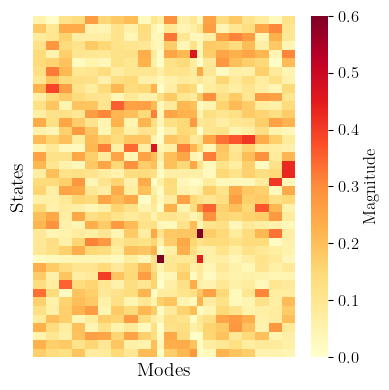

In [6]:

from plot_function import plot_participation_factors

for key, model in models.items():
    modes = np.abs(model._eigenvectors_)  # (n_features, n_modes)
    filename = f"participation_nice_complete.pdf"
    plot_participation_factors(modes, filename=filename)